# RlLib pour le couloir

Jusqu'à présent nous avons fait usage de StableBaselines qui est très facile à utiliser.
Mais d'autres librairies existent, comme RLlib

## Importations

In [1]:
# LES ALGORITHMES
# Pour StableBaselines
from QLearning import *
from DQN import *
from PPO import *
from helperPlot import *

# Pour RLLib
from ray.rllib.algorithms.dqn import DQNConfig
from ray.rllib.connectors.env_to_module import FlattenObservations
from ray import train, tune
from rllib_helper import *

# Aide
import time
from pprint import pprint

# POUR AFFICHAGE
import matplotlib.pyplot as plt
import seaborn as sns

# POUR ENVIRONNEMENT
import gymnasium
from gymnasium import spaces

## Environnement

In [2]:
class LineWorldEnv(gymnasium.Env):
    def __init__(self, options = None):
        super(LineWorldEnv, self).__init__()
        n_states = options['n_states']
        self.n_states = n_states
        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Discrete(n_states)
        self.state = 0

    def reset(self, seed = None, options = None):
        super().reset(seed = seed)
        self.state = 0
        return self.state, {}

    def step(self, action):
        if action == 0 and self.state > 0:
            self.state -= 1
        elif action == 1 and self.state < self.n_states - 1:
            self.state += 1
        done = self.state == self.n_states - 1
        reward = 10 if done else -1
        return self.state, reward, done, False, {}

    def render(self):
        print("État actuel :", self.state)

## Entraînement DQN RLlib couloir taille 10

In [3]:
# Configure the algorithm.
config = (
    DQNConfig()
    .environment(
        LineWorldEnv,
        env_config = {'n_states' : 10},
    )
    
    .env_runners(
        # Observations are discrete (ints) -> We need to flatten (one-hot) them.
        env_to_module_connector=lambda env: FlattenObservations(),
    )


    # Specify a simple tune hyperparameter sweep.
    .training(
        lr = tune.grid_search([0.001, 0.01, 0.1]),
        gamma = tune.grid_search([0.9, 0.99])
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[2], [8], [16], [32]])
        }
    )
)



# Create a Tuner instance to manage the trials.
tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    # Specify a stopping criterion. Note that the criterion has to match one of the
    # pretty printed result metrics from the results returned previously by
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": 10000},
    ),
)
# Run the Tuner and capture the results.
results = tuner.fit()


2025-06-16 09:52:32,740	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=6539) 2025-06-16 09:52:38,127	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=6541) 2025-06-16 09:52:38,850	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RL

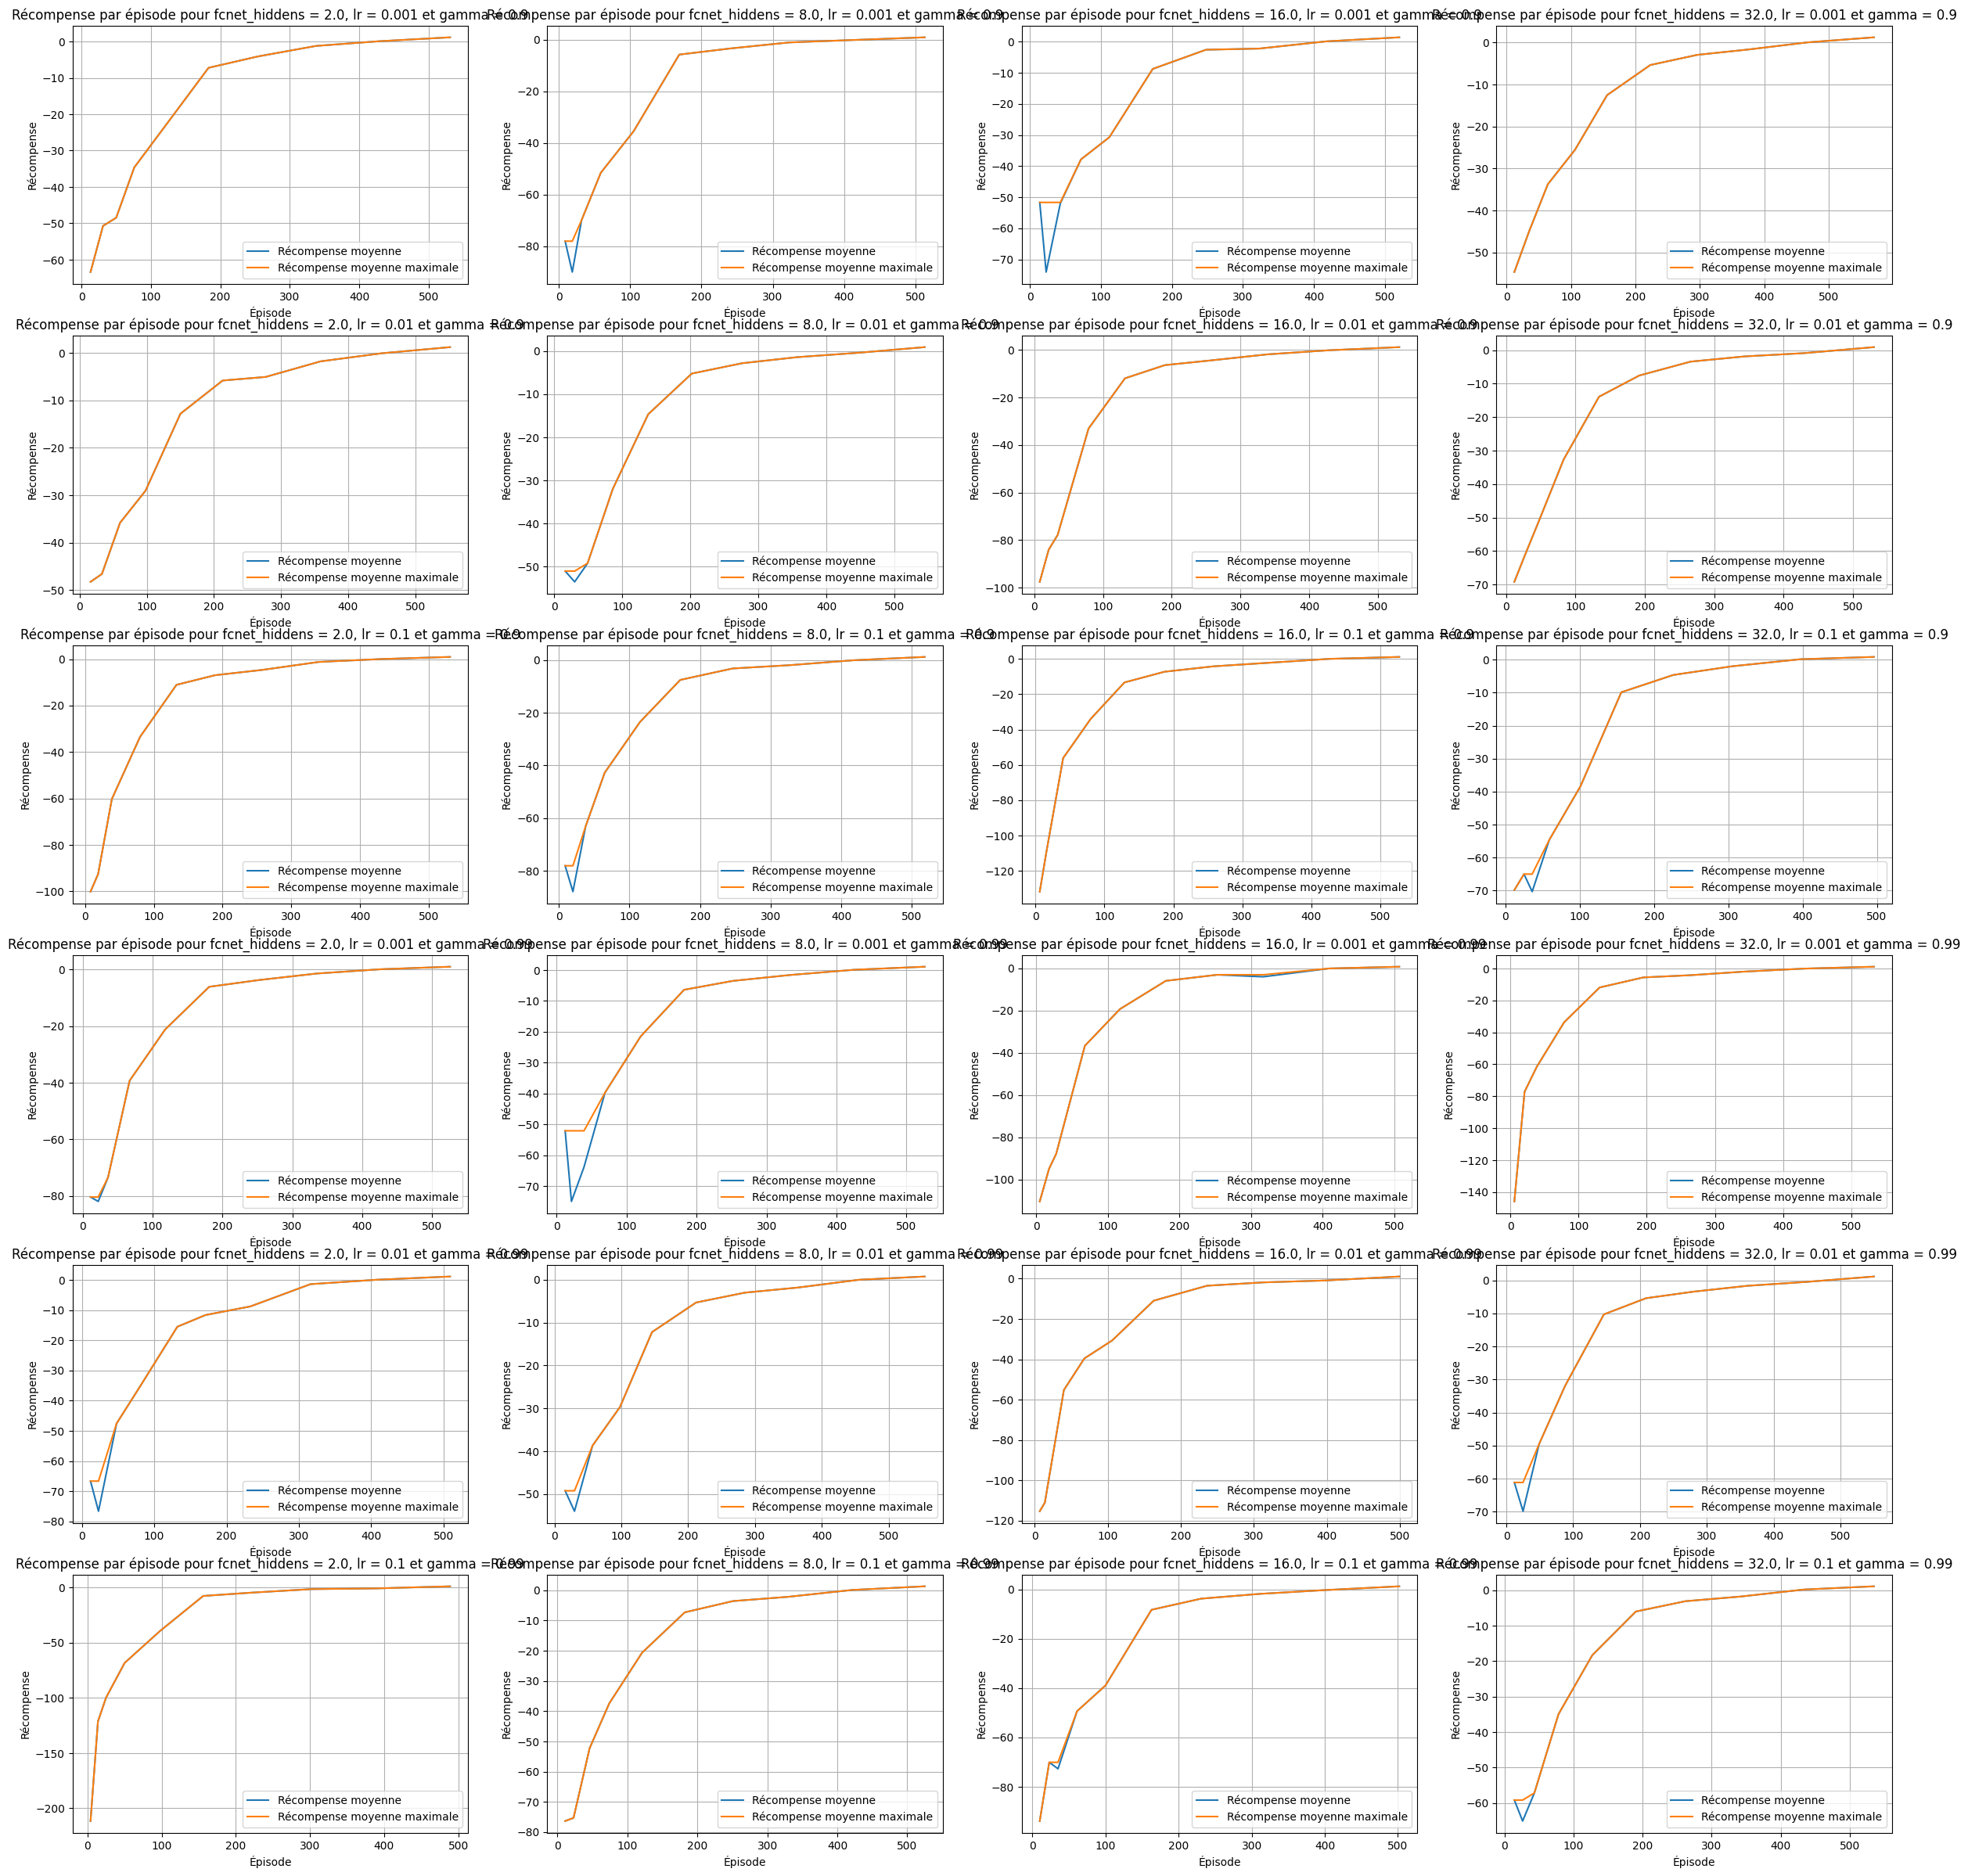

In [4]:
comparison_plot_3(results,
                  "fcnet_hiddens", [2., 8., 16., 32.],
                  "lr", [0.001, 0.01, 0.1],
                  "gamma", [0.9, 0.99]
                 )

Meilleurs résultats obtenus pour :
- fcnet_hiddens = [2]
- lr = 0.1
- gamma = 0.99

## Entraînement DQN RLlib couloir taille 40

In [5]:
# Configure the algorithm.
config = (
    DQNConfig()
    .environment(
        LineWorldEnv,
        env_config = {'n_states' : 40},
    )
    
    .env_runners(
        # Observations are discrete (ints) -> We need to flatten (one-hot) them.
        env_to_module_connector=lambda env: FlattenObservations(),
    )


    # Specify a simple tune hyperparameter sweep.
    .training(
        lr = tune.grid_search([0.01, 0.1, 1]),
        gamma = tune.grid_search([0.9, 0.99])
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[2], [8], [16], [32]])
        }
    )
)



# Create a Tuner instance to manage the trials.
tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    # Specify a stopping criterion. Note that the criterion has to match one of the
    # pretty printed result metrics from the results returned previously by
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": 10000},
    ),
)
# Run the Tuner and capture the results.
results = tuner.fit()

2025-06-16 10:30:51,738	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/enzo/ray_results/DQN_2025-06-16_10-12-50' in 0.1039s.
2025-06-16 10:30:51,745	INFO tune.py:1041 -- Total run time: 1081.02 seconds (1080.90 seconds for the tuning loop).


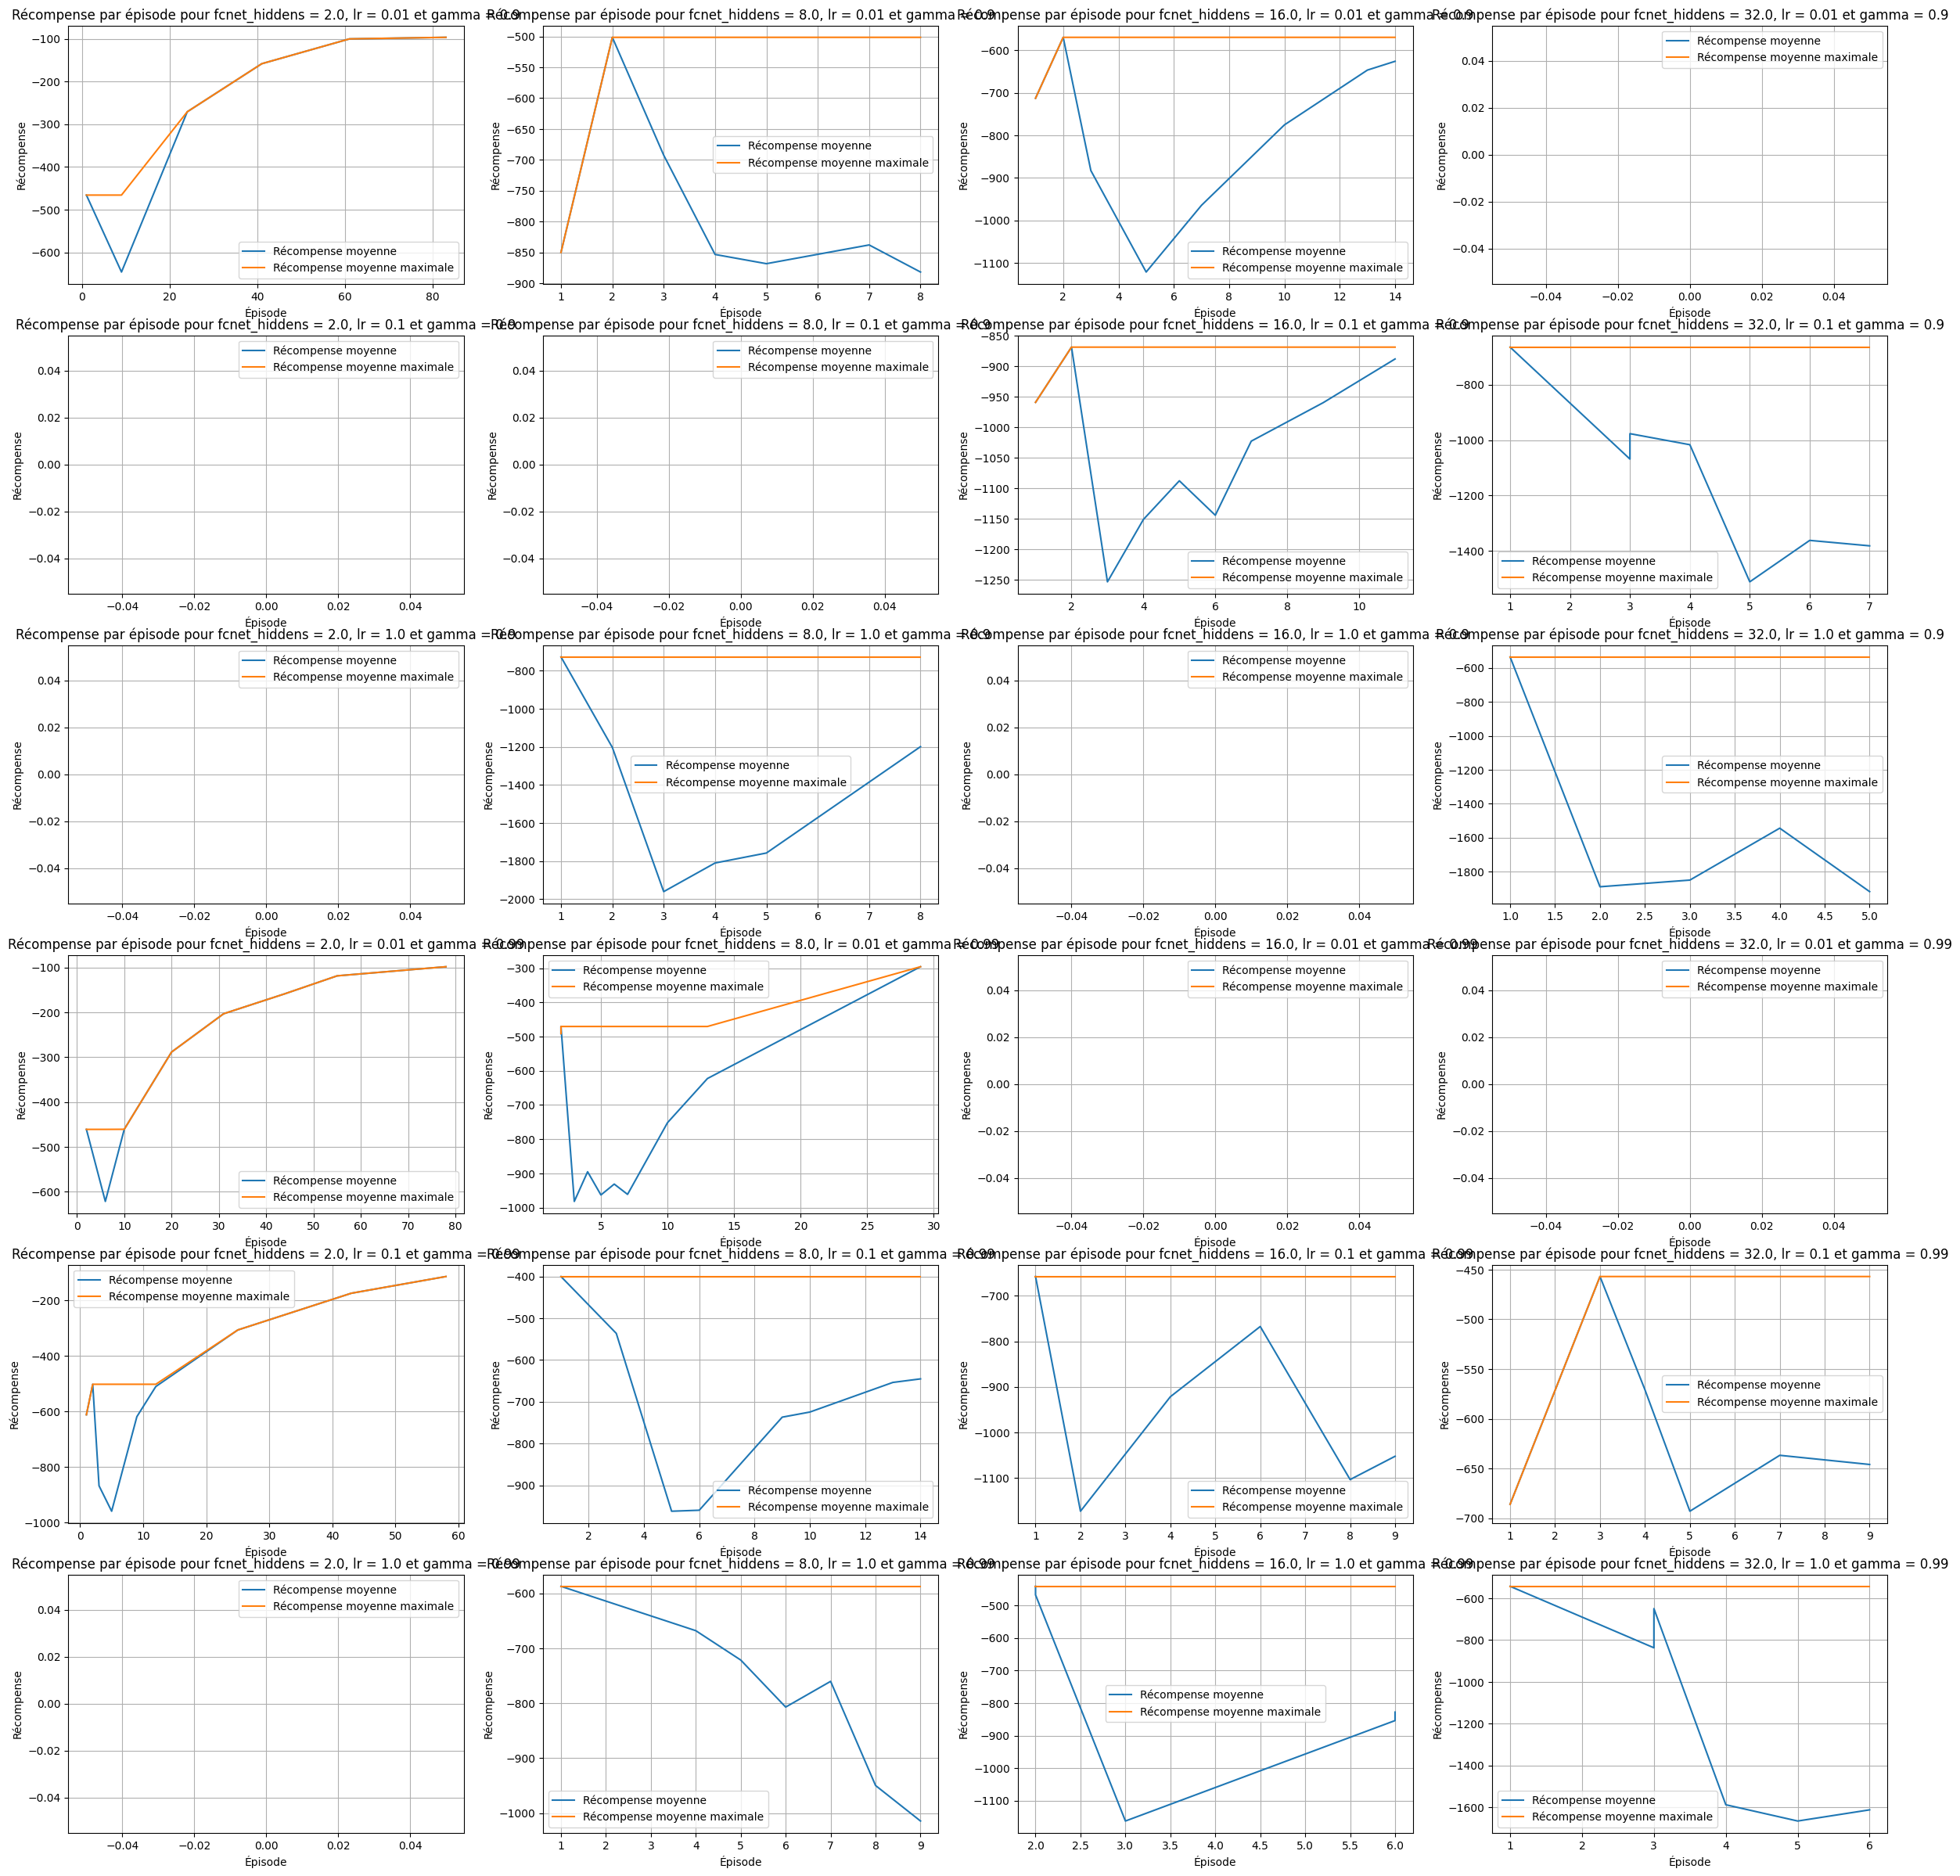

In [7]:
comparison_plot_3(results,
                  "fcnet_hiddens", [2., 8., 16., 32.],
                  "lr", [0.01, 0.1, 1.],
                  "gamma", [0.9, 0.99]
                 )

On conserve une architecture de [2], on préfère un lr de 0.01 et gamma = 0.9.

D'autres paramètres auront peut-être plus d'influence.

Jusqu'à présent les observations effectuées sont identiques à celles obtenues en utilisant StableBaselines.

Comparons StableBaselines et RlLib avec une configuration similaire pour les deux DQN (en raison du grand nombre de paramètres et le fait que par défaut ils n'ont pas les même valeurs, on choisit d'harmoniser les paramètres ayant eu un grand impact sur les observations effectuées)

## Comparaison RlLib / StableBaselines

2025-06-16 13:36:41,192	WARNING util.py:61 -- Install gputil for GPU system monitoring.
2025-06-16 13:37:11,929	WARNING util.py:61 -- Install gputil for GPU system monitoring.
2025-06-16 13:38:32,463	WARNING util.py:61 -- Install gputil for GPU system monitoring.
2025-06-16 13:41:31,262	WARNING util.py:61 -- Install gputil for GPU system monitoring.


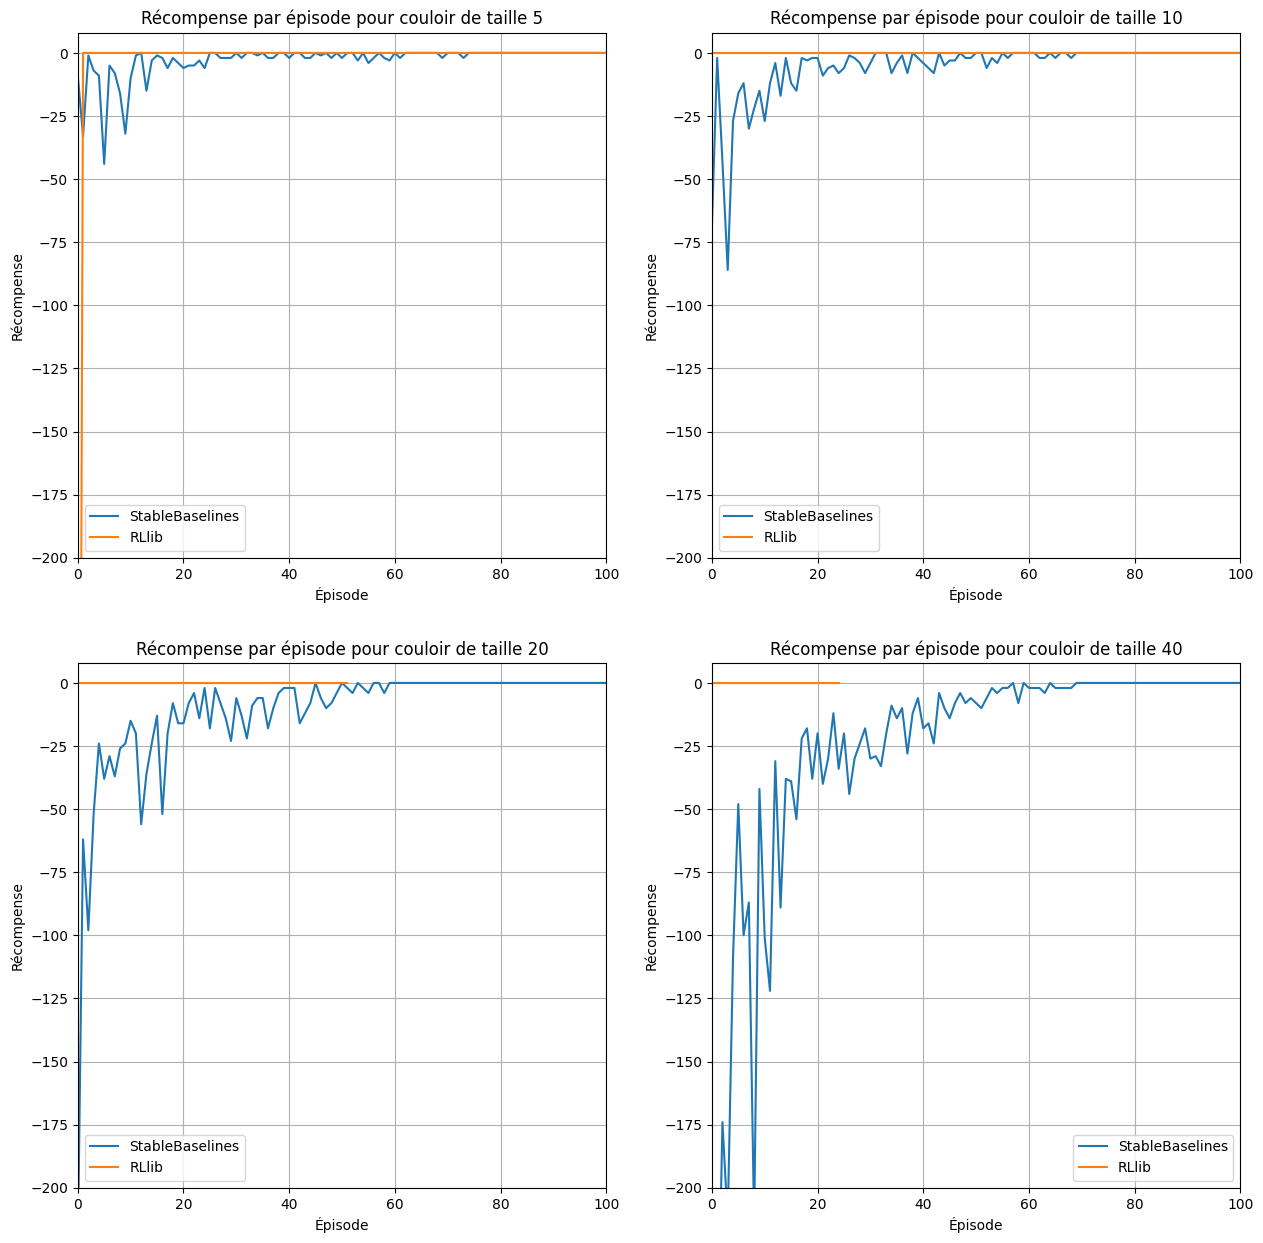

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
data = [(5, 0, 0, 2000, ([2], 1, 0, 0.01, 5)), (10, 0, 1, 4000, ([2], 1, 0, 0.01, 5)), 
        (20, 1, 0, 8000, ([2], 1, 0, 0.01, 5)), (40, 1, 1, 20000, ([2], 1, 0, 0.01, 5))]

for size, x, y, timesteps, (net_arch, eps_start, eps_end, lr, update_freq) in data :
    env = LineWorldEnv({'n_states' : size})
    
    modelOpti, trainRewards, prodRewards = train_dqn(env, timesteps = timesteps, useProdForReward = False, 
                                                     net_arch = net_arch,
                                                     exploration_initial_eps = eps_start,
                                                     exploration_final_eps = eps_end,
                                                     learning_rate = lr,
                                                     update_freq = update_freq,
                                                     gamma = 0.99
                                                    )
    
    
    axes[x ,y].plot([r - (12 - size) for r in trainRewards], label = 'StableBaselines')



    # Configure the algorithm.
    config = (
        DQNConfig()
        .environment(
            LineWorldEnv,
            env_config = {'n_states' : size}
        )
        
        .env_runners(
            # Observations are discrete (ints) -> We need to flatten (one-hot) them.
            env_to_module_connector=lambda env: FlattenObservations(),
        )
    
    
        # Specify a simple tune hyperparameter sweep.
        .training(
            lr = 0.01,
            gamma = 0.99,
            target_network_update_freq = 5,
            train_batch_size_per_learner = 32,
            epsilon = [[0, 1], [timesteps // 2, 0]],
            replay_buffer_config = {
                "capacity" : 2000
            },
            double_q = True
        )

        .callbacks(EvaluationCallback)

        
        .rl_module(
            model_config = {
                "fcnet_hiddens" : [2]
            }
        )

    )

    algo = config.build_algo()
    for _ in range(timesteps // 1000):
        resu = algo.train()
    axes[x, y].plot([r - (12 - size) for r in resu['env_runners']['episodes_rewards']], label = 'RLlib')

    axes[x, y].legend()
    axes[x ,y].set_xlabel("Épisode")
    axes[x ,y].set_ylabel("Récompense")
    axes[x ,y].set_title(f"Récompense par épisode pour couloir de taille {size}")
    axes[x ,y].grid()
    axes[x ,y].set_xlim([0, 100])
    axes[x ,y].set_ylim([-200, 8])
plt.show()


Nous remarquons qu'en terme d'épisodes, RLlib est bien plus efficace.
Néanmoins en raison des différences d'implémentation (notemment pour le replay buffer), RLlib nécessite beaucoup plus de steps ce qui rend son entraînement très lent.

# Conclusion

Il existe des différences entre StableBaselines et RLlib.

StableBaselines utilise le Hindsight Experience Replay pour replay buffer contrairement à RLlib qui ne contient pas d'implémentation de ce buffer.

Le buffer utilisé par RLlib nécessite une plus grande taille.


En raison de ces différences avec StableBaselines, RLlibe a besoin de plus steps pour accomplir moins d'épisodes, l'entraînement est plus lent.
Néanmoins, il est tout à fait possible d'obtenir de bons résultats avec RLlib et StableBaselines ne permet pas de faire de MARL.

Nous continuerons avec RLlib pour les prochains problèmes.